# Solution: Lab 5a Adversarial Attack on a Malware Classifier

This is the instructor solution version of lab 5a.

## Acknowledgement

This module was developed under the National Science Foundation awards # 2416990, 2416992 and 2607393 at Tennessee Tech University, North Carolina A&T State University and University of Albany.  

## Setup

In [ ]:
# NOTHING TO DO HERE - JUST RUN CELL
# Install needed modules
!pip install kagglehub keras shap tensorflow tensorflow_datasets ipywidgets matplotlib scikit-learn

In [1]:
# Runtime setup
import os
from pathlib import Path

# Keep TensorFlow logs quieter in notebook output.
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

LABELS = [
    "Gatak", "Kelihos_ver1", "Kelihos_ver3", "Lollipop",
    "Obfuscator_ACY", "Ramnit", "Tracur", "Vundo"
]

MODEL_PATH = Path("MalwareClassifier.h5")
SAMPLE_PATH = Path("gatak_only/Gatak/DsXzfyoVUlSAm8PwtZOB.bytes.png")

def running_in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def ensure_lab_files():
    """Find or upload the model and sample image needed by this notebook."""
    if MODEL_PATH.exists() and SAMPLE_PATH.exists():
        print("Found lab files in the current working directory.")
        return

    if not running_in_colab():
        missing = [str(p) for p in [MODEL_PATH, SAMPLE_PATH] if not p.exists()]
        raise FileNotFoundError(
            "Missing required lab file(s): " + ", ".join(missing) +
            ". Run this notebook from the lab directory or upload the files."
        )

    from google.colab import files
    print("Upload MalwareClassifier.h5 and DsXzfyoVUlSAm8PwtZOB.bytes.png when prompted.")
    uploaded = files.upload()

    if not MODEL_PATH.exists() and "MalwareClassifier.h5" in uploaded:
        Path("MalwareClassifier.h5").write_bytes(uploaded["MalwareClassifier.h5"])

    sample_name = "DsXzfyoVUlSAm8PwtZOB.bytes.png"
    if not SAMPLE_PATH.exists() and sample_name in uploaded:
        SAMPLE_PATH.parent.mkdir(parents=True, exist_ok=True)
        SAMPLE_PATH.write_bytes(uploaded[sample_name])

    if not MODEL_PATH.exists() or not SAMPLE_PATH.exists():
        raise FileNotFoundError("The model and sample PNG are both required before continuing.")

ensure_lab_files()
print("TensorFlow:", tf.__version__)
print("Keras:", getattr(keras, "__version__", "unknown"))


Found lab files in the current working directory.
TensorFlow: 2.21.0
Keras: 3.15.0


## Load the Model and Sample

In [2]:
# Load the sample image and the pre-trained malware classifier.
def load_sample_image(path=SAMPLE_PATH):
    image = keras.utils.load_img(path, target_size=(64, 64), color_mode="rgb")
    array = keras.utils.img_to_array(image).astype("float32") / 255.0
    return np.expand_dims(array, axis=0)

x_original = load_sample_image()
y_true = np.zeros((1, len(LABELS)), dtype="float32")
y_true[0, LABELS.index("Gatak")] = 1.0

# compile=False avoids legacy optimizer warnings from the older .h5 export.
malware_model = keras.models.load_model(MODEL_PATH, compile=False)
malware_model.summary()


/home/samuel/code_projects/6a/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 62, 62, 30)     │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 31, 31, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 29, 29, 15)     │         4,065 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 15)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 15)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2940)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       376,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,353 (1.50 MB)

 Trainable params: 392,353 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Prediction and plotting helpers.
def format_percent(value):
    return f"{value * 100:.6f}".rstrip("0").rstrip(".")

def prediction_table(probabilities):
    probabilities = np.asarray(probabilities).reshape(-1)
    rows = []
    for label, probability in zip(LABELS, probabilities):
        rows.append((label, probability, format_percent(probability)))
    return rows

def top_prediction(probabilities):
    probabilities = np.asarray(probabilities).reshape(-1)
    index = int(np.argmax(probabilities))
    return LABELS[index], float(probabilities[index])

def print_prediction(probabilities):
    label, confidence = top_prediction(probabilities)
    print(f"Prediction: {label} ({format_percent(confidence)}% confidence)")
    print()
    print("Class probabilities:")
    for label_name, probability, percent in prediction_table(probabilities):
        print(f"  {label_name:15s} {percent:>12s}%")

def show_image(image, title):
    plt.figure(figsize=(4, 4))
    plt.imshow(np.clip(image, 0, 1))
    plt.title(title)
    plt.axis("off")
    plt.show()


## 1. Original Sample

Expected answer: the provided unedited sample is a Gatak sample, and this model classifies it as `Gatak` with effectively 100% confidence.

In [4]:
# Prediction on the unedited Gatak sample.
base_probabilities = malware_model.predict(x_original, verbose=0)[0]
print_prediction(base_probabilities)
base_label, base_confidence = top_prediction(base_probabilities)
show_image(x_original[0], f"Original sample\n{base_label}: {format_percent(base_confidence)}% confidence")


InternalError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/samuel/code_projects/6a/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/samuel/code_projects/6a/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1082, in launch_instance

  File "/home/samuel/code_projects/6a/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 807, in start

  File "/home/samuel/code_projects/6a/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 641, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1987, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/home/samuel/code_projects/6a/.venv/lib/python3.

## 2. Adversarial Pattern

The pattern below is the signed gradient of the categorical cross-entropy loss with respect to the input image.

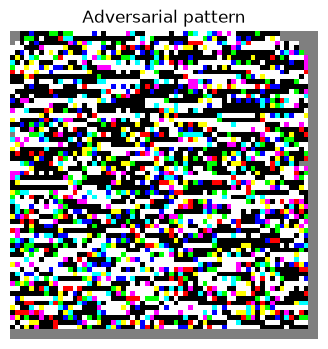

In [ ]:
# FGSM adversarial pattern.
# This follows the TensorFlow FGSM tutorial approach: take the sign of the
# gradient of the loss with respect to the input image.
loss_object = tf.keras.losses.CategoricalCrossentropy()

def create_adversarial_pattern(input_image, input_label):
    input_image = tf.convert_to_tensor(input_image, dtype=tf.float32)
    input_label = tf.convert_to_tensor(input_label, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = malware_model(input_image)
        loss = loss_object(input_label, prediction)

    gradient = tape.gradient(loss, input_image)
    signed_gradient = tf.sign(gradient)
    return signed_gradient.numpy()

perturbation = create_adversarial_pattern(x_original, y_true)
show_image(perturbation[0] * 0.5 + 0.5, "Adversarial pattern")


## 3. Original Script Attack at Epsilon 0.15

Expected answer: with `epsilon = 0.15`, the model misclassifies the adversarial sample as `Ramnit` with effectively 100% confidence. Rerunning the same model, image, and epsilon should produce the same prediction because inference and the FGSM calculation are deterministic here.

Prediction: Ramnit (100% confidence)

Class probabilities:
  Gatak                      0%
  Kelihos_ver1               0%
  Kelihos_ver3               0%
  Lollipop                   0%
  Obfuscator_ACY             0%
  Ramnit                   100%
  Tracur                     0%
  Vundo                      0%


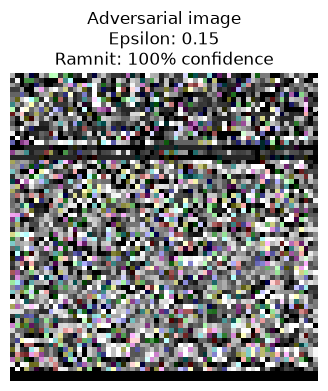

In [ ]:
# Create the adversarial image used in the original script.
epsilon = 0.15

adv_image = x_original.copy()
adv_image[0] = adv_image[0] + epsilon * perturbation[0]

adv_probabilities = malware_model.predict(adv_image, verbose=0)[0]
print_prediction(adv_probabilities)
adv_label, adv_confidence = top_prediction(adv_probabilities)
show_image(
    adv_image[0],
    f"Adversarial image\nEpsilon: {epsilon}\n{adv_label}: {format_percent(adv_confidence)}% confidence",
)


## 4. Fine-Tuned Epsilon

Among two-decimal epsilon values tested from `0.00` upward, `0.01` is the smallest value that flips the model from `Gatak` to `Ramnit` for the provided files. It is a good answer for this lab because the visual change is small while the classifier is disrupted.

epsilon=0.00 -> Gatak                    100% (Gatak confidence: 100%)


epsilon=0.01 -> Ramnit             84.990531% (Gatak confidence: 14.958511%)
epsilon=0.02 -> Ramnit             99.998748% (Gatak confidence: 0.000648%)


epsilon=0.03 -> Ramnit             99.999857% (Gatak confidence: 0.000041%)


epsilon=0.04 -> Ramnit             99.999976% (Gatak confidence: 0.000005%)
epsilon=0.05 -> Ramnit                   100% (Gatak confidence: 0.000001%)


epsilon=0.10 -> Ramnit                   100% (Gatak confidence: 0%)
epsilon=0.15 -> Ramnit                   100% (Gatak confidence: 0%)
epsilon=0.20 -> Ramnit                   100% (Gatak confidence: 0%)


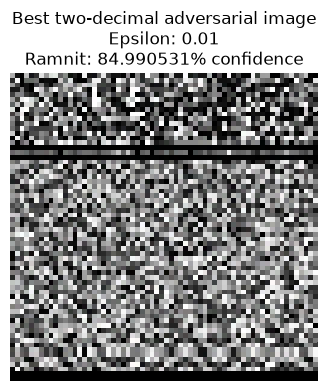

In [ ]:
# Sweep epsilon values. The lab asks for two decimal places, so 0.01 is the
# smallest value in this sweep that changes the model's prediction.
epsilon_values = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.10, 0.15, 0.20]
results = []

for eps in epsilon_values:
    candidate = x_original.copy()
    candidate[0] = candidate[0] + eps * perturbation[0]
    probabilities = malware_model.predict(candidate, verbose=0)[0]
    label, confidence = top_prediction(probabilities)
    results.append((eps, label, confidence, probabilities[LABELS.index("Gatak")]))
    print(
        f"epsilon={eps:>4.2f} -> {label:15s} "
        f"{format_percent(confidence):>12s}% "
        f"(Gatak confidence: {format_percent(probabilities[0])}%)"
    )

best_epsilon = 0.01
best_image = x_original.copy()
best_image[0] = best_image[0] + best_epsilon * perturbation[0]
best_probabilities = malware_model.predict(best_image, verbose=0)[0]
best_label, best_confidence = top_prediction(best_probabilities)
show_image(
    best_image[0],
    f"Best two-decimal adversarial image\nEpsilon: {best_epsilon}\n{best_label}: {format_percent(best_confidence)}% confidence",
)


## Final Answers

- Original sample classification: `Gatak`, effectively 100% confidence.
- At `epsilon = 0.15`: misclassified as `Ramnit`, effectively 100% confidence.
- Repeated runs: same prediction and confidence are expected for the same files and software behavior.
- Best two-decimal epsilon from this sweep: `0.01`.
- At `epsilon = 0.01`: misclassified as `Ramnit`, about 84.99% confidence, with much less visible change than larger epsilon values.